In [53]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import fmin

In [54]:
#ABs
def gr_L(T_l, A_l, check_tol=1e-6):

    N = T_l.shape[0]
    I = np.eye(N)
    Tmat = np.block([
        [np.linalg.inv(T_l) @ A_l, -np.linalg.inv(T_l) @ T_l.conj().T],
        [I, np.zeros((N, N))]
    ])

    eigvals, eigvecs = eig(Tmat)


    idx = np.argsort(np.abs(eigvals))
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    lambdas = eigvals[:N]
    vecs = eigvecs[:, :N]

    S1 = vecs[:N, :] 
    S2 = vecs[N:, :]  

    gL = np.linalg.inv(A_l - T_l @ S1 @ np.linalg.inv(S2))
    check = (A_l - T_l @ gL @ T_l.conj().T) @ gL - I
    max_err = np.max(np.abs(check))

    #if max_err > check_tol:
    #    mag = np.abs(eigvals)
    #    print("Sorted |eigvals|:", np.sort(mag))
    #    raise RuntimeError(
    #        fr"Self-consistency violated: max |Δ| = {max_err}"
    #    )
    return gL

def zinengr_L(T_LD_wei ,gr_L_wei):
    return T_LD_wei.conj().T @ gr_L_wei @ T_LD_wei

def Gr_DD_quan(H_q, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, E, eta=1e-6):
    d = H_q.shape[0]
    I = np.eye(d, dtype=complex)
    Z = np.zeros((d, d), dtype=complex)

    EI_gai = np.block([
        [(E + 1j*eta)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (E + 1j*eta)*s0]
    ])

    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)


    A_DD = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):

        if i == 0:
            A_DD[i][i] = EI_gai - H_q - Sigma_L
        elif i == N-1:
            A_DD[i][i] = EI_gai - H_q - Sigma_R
        else:
            A_DD[i][i] = EI_gai - H_q

        if i < N-1:
            A_DD[i][i+1] = -T_12

        if i > 0:
            A_DD[i][i-1] = -T_12.conj().T

    g_ii = [np.zeros((d, d), dtype=complex) for _ in range(N)]

    d_R = [np.zeros((d, d), dtype=complex) for _ in range(N)]
    c_R = [np.zeros((d, d), dtype=complex) for _ in range(N)]#第一个是0
    for i in range(N-1,-1,-1):
        if i==N-1:
            d_R[i]=A_DD[i][i]
        else:
            c_R[i+1]=-1*A_DD[i][i+1] @ np.linalg.inv(d_R[i+1])
            d_R[i]=A_DD[i][i]+c_R[i+1] @ A_DD[i+1][i]

    d_L = [np.zeros((d, d), dtype=complex) for _ in range(N)]
    c_L = [np.zeros((d, d), dtype=complex) for _ in range(N)]#最后一个是0

    for i in range(N):
        if i==0:
            d_L[i]=A_DD[i][i]
        else:
            c_L[i-1]=-1*A_DD[i][i-1] @ np.linalg.inv(d_L[i-1])
            d_L[i]=A_DD[i][i]+ c_L[i-1] @ A_DD[i-1][i]

        g_ii[i]=np.linalg.inv(-A_DD[i][i]+d_L[i]+d_R[i])

    G_DD_r = [[Z.copy() for _ in range(N)] for _ in range(N)]
    for i in range(N):
        for j in range(N):

            if i == j:
                G_DD_r[i][j] = g_ii[i]

            elif i > j:
                prod = np.eye(d, dtype=complex)
                for k in range(i-1, j-1, -1):
                    prod = prod @ c_L[k]
                G_DD_r[i][j] = g_ii[i] @ prod


            else:  
                prod = np.eye(d, dtype=complex)
                for k in range(i+1, j+1):
                    prod = prod @ c_R[k]
                G_DD_r[i][j] = g_ii[i] @ prod

    G_DD_r = np.block(G_DD_r)
    A_DD = np.block(A_DD)
    return G_DD_r , A_DD , Sigma_R , Sigma_L 

def Gr_DD_kuaisanjiao(H_q, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, E, eta=3e-6):
    d = H_q.shape[0]
    I = np.eye(d, dtype=complex)
    Z = np.zeros((d, d), dtype=complex)

    EI_gai = np.block([
        [(E + 1j*eta)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (E + 1j*eta)*s0]
    ])

    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)


    A_DD = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):

        if i == 0:
            A_DD[i][i] = EI_gai - H_q - Sigma_L
        elif i == N-1:
            A_DD[i][i] = EI_gai - H_q - Sigma_R
        else:
            A_DD[i][i] = EI_gai - H_q

        if i < N-1:
            A_DD[i][i+1] = -T_12

        if i > 0:
            A_DD[i][i-1] = -T_12.conj().T

    g_ii = [np.zeros((d, d), dtype=complex) for _ in range(N)]

    d_R = [np.zeros((d, d), dtype=complex) for _ in range(N)]
    c_R = [np.zeros((d, d), dtype=complex) for _ in range(N)]#第一个是0
    for i in range(N-1,-1,-1):
        if i==N-1:
            d_R[i]=A_DD[i][i]
        else:
            c_R[i+1]=-1*A_DD[i][i+1] @ np.linalg.inv(d_R[i+1])
            d_R[i]=A_DD[i][i]+c_R[i+1] @ A_DD[i+1][i]

    d_L = [np.zeros((d, d), dtype=complex) for _ in range(N)]
    c_L = [np.zeros((d, d), dtype=complex) for _ in range(N)]#最后一个是0

    for i in range(N):
        if i==0:
            d_L[i]=A_DD[i][i]
        else:
            c_L[i-1]=-1*A_DD[i][i-1] @ np.linalg.inv(d_L[i-1])
            d_L[i]=A_DD[i][i]+ c_L[i-1] @ A_DD[i-1][i]

        g_ii[i]=np.linalg.inv(-A_DD[i][i]+d_L[i]+d_R[i])

    G_DD_r = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):
        G_DD_r[i][i] = g_ii[i]

    for i in range(N-1):
        G_DD_r[i][i+1] = g_ii[i] @ c_R[i+1]


    for i in range(N-1):
        G_DD_r[i+1][i] = g_ii[i+1] @ c_L[i]

    G_DD_r = np.block(G_DD_r)
    A_DD = np.block(A_DD)
    return G_DD_r , A_DD , Sigma_R , Sigma_L 

def Gr_DD(H_q,H_l,H_r,  T_12,T_LD,T_l,T_RD,T_r,  N,E,eta=3e-6):
    d = H_q.shape[0]
    I = np.eye(d, dtype=complex)
    Z = np.zeros((d, d), dtype=complex)

    EI_gai = np.block([
        [(E + 1j*eta)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (E + 1j*eta)*s0]
    ])

    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)


    A_DD = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):

        if i == 0:
            A_DD[i][i] = EI_gai - H_q - Sigma_L
        elif i == N-1:
            A_DD[i][i] = EI_gai - H_q - Sigma_R
        else:
            A_DD[i][i] = EI_gai - H_q

        if i < N-1:
            A_DD[i][i+1] = -T_12

        if i > 0:
            A_DD[i][i-1] = -T_12.conj().T
    A_DD = np.block(A_DD)
    G_DD_r = np.linalg.inv(A_DD)
    return G_DD_r , A_DD ,Sigma_R ,Sigma_L 
    
def bufeng(G_DD_r):
    d = H_q.shape[0]
    yigeshu=np.trace(G_DD_r[q*d:(q+1)*d, (q)*d:(q+1)*d])
    return -np.imag(yigeshu)/np.pi

def find_peaks_fmin(A_of_E, E_min, E_max, N_guess=11, xtol=1e-6, ftol=1e-6, round_digits=6):

    E_guesses = np.linspace(E_min, E_max, N_guess)
    peak_list = []

    for E0 in E_guesses:
        r = fmin(lambda E: -A_of_E(E), E0, disp=False, xtol=xtol, ftol=ftol)
        peak_list.append(r[0])

    peak_list = np.unique(np.round(peak_list, round_digits))
    return peak_list


#current
def Gr_DD_MS_quan(H_q, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, wn):
    d = H_q.shape[0]
    I = np.eye(d, dtype=complex)
    Z = np.zeros((d, d), dtype=complex)

    EI_gai = np.block([
        [(1j*wn)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (1j*wn)*s0]
    ])

    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)


    A_DD = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):

        if i == 0:
            A_DD[i][i] = EI_gai - H_q - Sigma_L
        elif i == N-1:
            A_DD[i][i] = EI_gai - H_q - Sigma_R
        else:
            A_DD[i][i] = EI_gai - H_q

        if i < N-1:
            A_DD[i][i+1] = -T_12

        if i > 0:
            A_DD[i][i-1] = -T_12.conj().T

    g_ii = [np.zeros((d, d), dtype=complex) for _ in range(N)]

    d_R = [np.zeros((d, d), dtype=complex) for _ in range(N)]
    c_R = [np.zeros((d, d), dtype=complex) for _ in range(N)]#第一个是0
    for i in range(N-1,-1,-1):
        if i==N-1:
            d_R[i]=A_DD[i][i]
        else:
            c_R[i+1]=-1*A_DD[i][i+1] @ np.linalg.inv(d_R[i+1])
            d_R[i]=A_DD[i][i]+c_R[i+1] @ A_DD[i+1][i]

    d_L = [np.zeros((d, d), dtype=complex) for _ in range(N)]
    c_L = [np.zeros((d, d), dtype=complex) for _ in range(N)]#最后一个是0

    for i in range(N):
        if i==0:
            d_L[i]=A_DD[i][i]
        else:
            c_L[i-1]=-1*A_DD[i][i-1] @ np.linalg.inv(d_L[i-1])
            d_L[i]=A_DD[i][i]+ c_L[i-1] @ A_DD[i-1][i]

        g_ii[i]=np.linalg.inv(-A_DD[i][i]+d_L[i]+d_R[i])


    G_DD_r = [[Z.copy() for _ in range(N)] for _ in range(N)]
    for i in range(N):
        for j in range(N):

            if i == j:
                G_DD_r[i][j] = g_ii[i]

            elif i > j:
                prod = np.eye(d, dtype=complex)
                for k in range(i-1, j-1, -1):
                    prod = prod @ c_L[k]
                G_DD_r[i][j] = g_ii[i] @ prod


            else:  
                prod = np.eye(d, dtype=complex)
                for k in range(i+1, j+1):
                    prod = prod @ c_R[k]
                G_DD_r[i][j] = g_ii[i] @ prod


    G_DD_wn = np.block(G_DD_r)
    A_DD_wn = np.block(A_DD)
    return G_DD_wn , A_DD_wn , Sigma_R , Sigma_L 

def Gr_DD_MS(H_q, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, wn):
    d = H_q.shape[0]
    I = np.eye(d, dtype=complex)
    Z = np.zeros((d, d), dtype=complex)

    EI_gai = np.block([
        [(1j*wn)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (1j*wn)*s0]
    ])

    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)


    A_DD = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):

        if i == 0:
            A_DD[i][i] = EI_gai - H_q - Sigma_L
        elif i == N-1:
            A_DD[i][i] = EI_gai - H_q - Sigma_R
        else:
            A_DD[i][i] = EI_gai - H_q

        if i < N-1:
            A_DD[i][i+1] = -T_12

        if i > 0:
            A_DD[i][i-1] = -T_12.conj().T

    A_DD_wn = np.block(A_DD)
    G_DD_wn = np.linalg.inv(A_DD_wn)
    return G_DD_wn , A_DD_wn , Sigma_R , Sigma_L 

def Gr_DD_MS_gaiyixia(H_q, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, wn):
    d = H_q.shape[0]
    I = np.eye(d, dtype=complex)
    Z = np.zeros((d, d), dtype=complex)

    EI_gai = np.block([
        [(1j*wn)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (1j*wn)*s0]
    ])

    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)


    A_DD = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):

        if i == 0:
            A_DD[i][i] = EI_gai - H_q - Sigma_L
        elif i == N-1:
            A_DD[i][i] = EI_gai - H_q - Sigma_R
        else:
            A_DD[i][i] = EI_gai - H_q

        if i < N-1:
            A_DD[i][i+1] = -T_12

        if i > 0:
            A_DD[i][i-1] = -T_12.conj().T

    A_DD_wn = np.block(A_DD)
    G_DD_wn = np.linalg.inv(A_DD_wn)
    f_E= 1/(1+np.exp((wn - mu)/KBT))
    G_DD_wn_xiao=f_E*(G_DD_wn.conj()-G_DD_wn)
    return G_DD_wn_xiao , A_DD_wn , Sigma_R , Sigma_L 

def J_wn(G_DD_wn, T_12, q):
    d = T_12.shape[0]

    G_q_q1 = G_DD_wn[q*d:(q+1)*d, (q+1)*d:(q+2)*d]
    G_q1_q = G_DD_wn[(q+1)*d:(q+2)*d, q*d:(q+1)*d]

    Jmat = T_12.conj().T @ G_q1_q - G_q_q1 @ T_12
    d_e = d //2
    return np.trace(Jmat[:d_e, :d_e])*(-1j)*KBT
    #return np.trace(Jmat)*(-1j)*KBT

def matsubara_list(shumu):
    n_max =  shumu
    n_vals = np.arange(-n_max, n_max+1 )
    wn = (2 * n_vals + 1) * np.pi * KBT

    return wn.tolist()

def J_matsubara_sum(shumu,H_q, H_l, H_r,T_12, T_LD, T_l, T_RD, T_r,N, q):
    wn_list = matsubara_list(shumu)
    J_sum = 0.0 
    for wn in wn_list:
        G_DD_wn, _, _, _ = Gr_DD_MS_gaiyixia(
            H_q, H_l, H_r,
            T_12, T_LD, T_l, T_RD, T_r,
            N, wn
        )

        J_sum += np.real(J_wn(G_DD_wn, T_12, q))
    return (J_sum)


In [55]:
#参数
m=2.5*10**(-3)
a=1


t =1/(2*m*a**2)
mu = 0

dela = 1
af=100
my=0.5
mz=0.5
mu=0

chaodaojiao = np.pi/2



#矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

#左边矩阵信息
HL_block=(-mu+2*t)*s0 + my*sy + mz*sz
Delta_L= -1j * dela * np.exp(-1j*chaodaojiao/2) * sy
H_L_onsite=np.block([
        [ HL_block,        Delta_L        ],
        [ Delta_L.conj().T, -HL_block.conj()]
    ])

H_L_right_to_left_hop_block=-1*(t*s0+1j*af*sy/(2*a))
H_L_right_to_left_hop=np.block([
        [ H_L_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_L_right_to_left_hop_block.conj()]
    ])

hop= H_L_right_to_left_hop
#中间矩阵信息
H_center_to_L= hop
H_R_to_center= hop

H_center_block= (-mu+2*t)*s0 + my*sy + mz*sz
H_center=np.block([
        [ H_center_block,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , -H_center_block.conj()]
    ])
    
H_center_right_to_left_hop= hop



#右边矩阵信息
HR_block= (-mu+2*t)*s0 + my*sy + mz*sz 
Delta_R= -1j * dela * np.exp(+1j*chaodaojiao/2) * sy
H_R_onsite=np.block([
        [ HR_block,        Delta_R        ],
        [ Delta_R.conj().T, -HR_block.conj()]
    ])

H_R_right_to_left_hop= hop



H_q=H_center
T_12= H_center_right_to_left_hop.conj().T

H_l= H_L_onsite
T_l= H_L_right_to_left_hop

H_r= H_R_onsite
T_r=H_R_right_to_left_hop.conj().T

T_LD=H_center_to_L.conj().T
T_RD= H_R_to_center


N=2
q=0
shumu=500
KBT=3.5*dela*1e-3

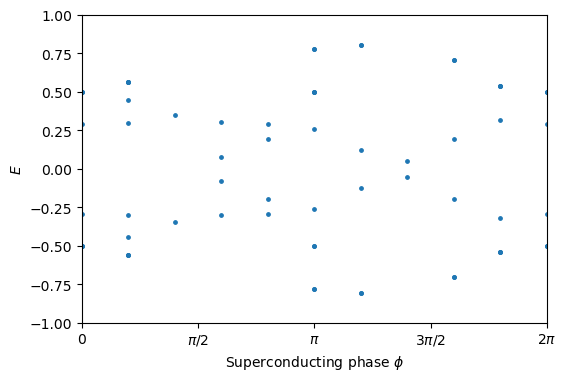

In [56]:
phi_set = np.linspace(0, 2*np.pi, 11)     # 超导相位
E_min, E_max = -dela, dela
phi_list = []
E_peak_list = []

for phi in phi_set:
    chaodaojiao = phi

    Delta_L = -dela * np.exp(-1j*chaodaojiao/2) * 1j * sy
    H_L_onsite = np.block([
        [ HL_block,          Delta_L ],
        [ Delta_L.conj().T, -HL_block.conj() ]
    ])

    Delta_R = -dela * np.exp(+1j*chaodaojiao/2) * 1j * sy
    H_R_onsite = np.block([
        [ HR_block,          Delta_R ],
        [ Delta_R.conj().T, -HR_block.conj() ]
    ])


    H_l = H_L_onsite
    H_r = H_R_onsite

    def A_of_E(E):
        G_DD_r, _, _, _ = Gr_DD(
            H_q, H_l, H_r,
            T_12, T_LD, T_l, T_RD, T_r,
            N, E
        )
        return bufeng(G_DD_r)


    peak_energies = find_peaks_fmin(A_of_E, E_min, E_max, N_guess=11, xtol=1e-5, ftol=1e-5)


    for E_peak in peak_energies:
        phi_list.append(phi)
        E_peak_list.append(E_peak)


plt.figure(figsize=(6,4))
plt.scatter(phi_list, E_peak_list, s=6)
plt.xlabel(r"Superconducting phase $\phi$")
plt.ylabel(r"$E$")
plt.xlim(0, 2*np.pi)
#plt.ylim(E_min, E_max)
plt.ylim(E_min, E_max)
plt.xticks(
    [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
    ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$']
)
plt.show()


C:\Users\taoji\AppData\Local\Temp\ipykernel_32816\3890259695.py:418: RuntimeWarning: overflow encountered in exp
  f_E= 1/(1+np.exp((wn - mu)/KBT))


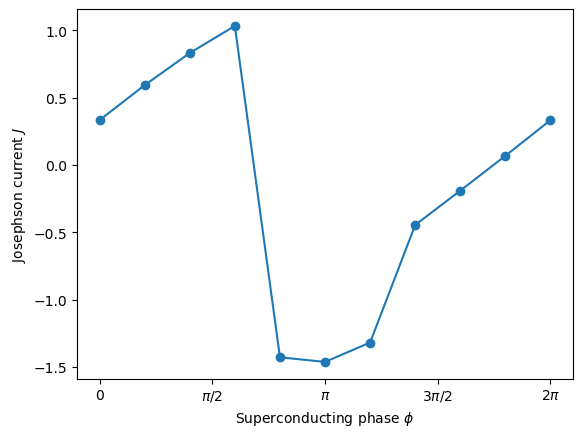

In [36]:
phi_list = np.linspace(0, 2*np.pi, 11)
J_list = []

for phi in phi_list:
    chaodaojiao = phi

    Delta_L = -dela * np.exp(-1j*phi/2) * 1j * sy
    H_l = np.block([
        [ HL_block,         Delta_L ],
        [ Delta_L.conj().T, -HL_block.conj() ]
    ])

    Delta_R = -dela * np.exp(+1j*phi/2) * 1j * sy
    H_r = np.block([
        [ HR_block,         Delta_R ],
        [ Delta_R.conj().T, -HR_block.conj() ]
    ])

    Jphi = J_matsubara_sum(
        shumu=shumu,
        H_q=H_q,
        H_l=H_l,
        H_r=H_r,
        T_12=T_12,
        T_LD=T_LD,
        T_l=T_l,
        T_RD=T_RD,
        T_r=T_r,
        N=N,
        q=q
    )

    J_list.append(Jphi)# 不知道发现了什么，加个1/2

plt.figure()
plt.plot(phi_list, J_list, marker='o')
plt.xlabel(r'Superconducting phase $\phi$')
plt.ylabel(r'Josephson current $J$')
plt.xticks(
    [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
    ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$']
)
plt.show()

